<a href="https://colab.research.google.com/github/nitka975/MachinelLearning/blob/main/NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Начало


In [1]:
!pip install nltk

In [2]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Завантажуємо ресурси NLTK
nltk.download('punkt')  # для токенізації
nltk.download('stopwords')  # список поширених слів (the, a, is...)
nltk.download('movie_reviews')  # корпус з відгуками


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


True

In [3]:
from nltk.corpus import movie_reviews
import random

# Створюємо список: (слова в відгуку, мітка - позитивний або негативний)
documents = [(list(movie_reviews.words(fileid)), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]

# Перемішуємо, щоб не було спочатку всі позитивні, а потім негативні
random.shuffle(documents)

In [4]:
print(documents[10])

(['let', 'me', 'begin', 'by', 'saying', 'that', 'this', 'is', 'easily', 'the', 'worst', 'movie', 'in', 'the', 'entire', 'official', '(', 'and', 'even', 'unofficial', ')', 'james', 'bond', 'series', '.', 'it', 'is', 'so', 'full', 'of', 'self', '-', 'parody', 'and', 'silly', 'characters', 'that', 'you', 'would', 'almost', 'believe', 'you', 'were', 'watching', 'a', 'spoof', '.', 'an', 'omen', 'of', 'what', 'is', 'to', 'come', 'is', 'provided', 'by', 'the', 'pre', '-', 'credits', 'sequence', ',', 'a', 'dull', 'affair', 'featuring', 'a', 'confrontation', 'between', 'a', 'man', '(', 'it', "'", 's', 'difficult', 'to', 'give', 'a', 'better', 'description', 'since', 'no', 'mention', 'of', 'him', 'is', 'made', 'elsewhere', 'in', 'the', 'movie', ')', 'and', 'the', 'assassin', 'of', 'the', 'title', '.', 'a', 'song', 'with', 'woefully', 'terrible', 'lyrics', 'follows', ',', 'and', 'the', 'rest', 'of', 'the', 'movie', 'is', 'even', 'worse', '.', 'the', 'plot', 'might', 'have', 'been', 'a', 'pleasant

In [5]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# d = {} -> dict() -> {'key1': 'value1', 'key2': 'value2'}
# s = set() -> {'val1', 'val2', 'val3'}
stop_words = set(stopwords.words('english'))
ps = PorterStemmer()

# Функція для очищення слів
def clear_words(words: list) -> list:
  return [ps.stem(w.lower()) for w in words if w.isalpha() and w.lower() not in stop_words]

In [6]:
print(stop_words)

{'s', 'into', "hadn't", "don't", 'itself', "it'll", 'does', "it'd", 'own', 'hers', 'to', "that'll", "wasn't", 'being', 'nor', 'do', 'other', 'from', 'but', "he'll", 'be', 'herself', "i've", 'who', 'why', 'so', 'ain', 'as', 've', 'a', 'myself', 'such', "you're", "it's", "wouldn't", 'too', 'very', 'off', "i'll", "i'd", 'been', 'd', 'y', 'hasn', "she's", 'further', 'his', 'did', 'weren', 'are', 'have', 'haven', 'about', "we'll", 'where', 'should', 'at', 'themselves', 'i', 'me', "haven't", 'mightn', 'most', 'needn', 'while', 'don', 'couldn', 'had', "shouldn't", 'the', 'before', 'above', 'its', 'out', 'once', 'they', "they'll", 'wouldn', 'an', "won't", 'were', 'in', 'than', 'up', 'won', 'between', 'until', 'has', 'yourselves', 'whom', 'then', 'now', 'ours', 'your', 'is', "weren't", 'can', 'on', 'and', 't', 'shouldn', 'more', 'having', 'if', 'll', 'that', "doesn't", "she'll", "you'd", "couldn't", 'her', "needn't", 'these', 'against', 'each', 'just', 'it', 'yourself', "they've", 'doesn', 'wit

In [7]:
# Очищення всіх документів
cleaned_documents = [(" ".join(clear_words(doc)), label) for doc, label in documents]

In [8]:
# a = [1, 2, 3]
# a, b, c = [1, 2, 3] -> a = 1, b = 2, c = 3

In [9]:
print(cleaned_documents[10])

('let begin say easili worst movi entir offici even unoffici jame bond seri full self parodi silli charact would almost believ watch spoof omen come provid pre credit sequenc dull affair featur confront man difficult give better descript sinc mention made elsewher movi assassin titl song woefulli terribl lyric follow rest movi even wors plot might pleasant chang usual rule world often found jame bond movi get confus mismash fabl assassin francisco scaramanga christoph lee put perform one rare save grace movi someon appar pay one million dollar order remov roger moor also flimsi connect energi crisi miss solar cell effici much mess sound bond help task mari goodnight ekland whose charact possibl closer stereotyp bimbo cours movi get lock closet car trunk blunder around control room accident set laser serv purpos enhanc plot whatsoev maud adam later star octopussi much stronger use charact hardli featur movi scaramanga lackey dwarf call nik nak rather fittingli also possibl silliest henc

In [10]:
print(documents[10])

(['let', 'me', 'begin', 'by', 'saying', 'that', 'this', 'is', 'easily', 'the', 'worst', 'movie', 'in', 'the', 'entire', 'official', '(', 'and', 'even', 'unofficial', ')', 'james', 'bond', 'series', '.', 'it', 'is', 'so', 'full', 'of', 'self', '-', 'parody', 'and', 'silly', 'characters', 'that', 'you', 'would', 'almost', 'believe', 'you', 'were', 'watching', 'a', 'spoof', '.', 'an', 'omen', 'of', 'what', 'is', 'to', 'come', 'is', 'provided', 'by', 'the', 'pre', '-', 'credits', 'sequence', ',', 'a', 'dull', 'affair', 'featuring', 'a', 'confrontation', 'between', 'a', 'man', '(', 'it', "'", 's', 'difficult', 'to', 'give', 'a', 'better', 'description', 'since', 'no', 'mention', 'of', 'him', 'is', 'made', 'elsewhere', 'in', 'the', 'movie', ')', 'and', 'the', 'assassin', 'of', 'the', 'title', '.', 'a', 'song', 'with', 'woefully', 'terrible', 'lyrics', 'follows', ',', 'and', 'the', 'rest', 'of', 'the', 'movie', 'is', 'even', 'worse', '.', 'the', 'plot', 'might', 'have', 'been', 'a', 'pleasant

In [11]:
# Створюємо таблицю
df = pd.DataFrame(cleaned_documents, columns=['review', 'label'])
df.head(11)

,review,label
0,saw trailer film laugh harder quit time theref...,pos
1,traffic violat dr daniel review u turn dr rate...,neg
2,houston seriou problem make mission imposs bri...,neg
3,susan granger review american outlaw warner br...,neg
4,reason human would must admit occasion befuddl...,neg
5,susan granger review glitter centuri fox less ...,neg
6,avail new video edit arrow entertain introduct...,pos
7,let say live end airport runway larg jetlin co...,pos
8,press screen moulin roug stood lobbi theater l...,pos
9,movi highli built truman show review boast fil...,pos


<Axes: title={'center': 'Розподіл відгуків'}, xlabel='label'>

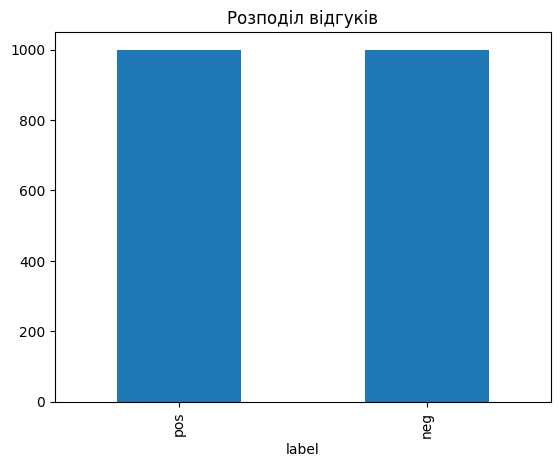

In [12]:
# Подивимося кількість позитивних і негативних
df['label'].value_counts().plot(kind='bar', title='Розподіл відгуків')

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['review'])  # матриця "слів" → "числа"
y = df['label']

In [14]:
# Створюємо таблицю
df = pd.DataFrame(cleaned_documents, columns=['review', 'label'])
df.head(11)

,review,label
0,saw trailer film laugh harder quit time theref...,pos
1,traffic violat dr daniel review u turn dr rate...,neg
2,houston seriou problem make mission imposs bri...,neg
3,susan granger review american outlaw warner br...,neg
4,reason human would must admit occasion befuddl...,neg
5,susan granger review glitter centuri fox less ...,neg
6,avail new video edit arrow entertain introduct...,pos
7,let say live end airport runway larg jetlin co...,pos
8,press screen moulin roug stood lobbi theater l...,pos
9,movi highli built truman show review boast fil...,pos


<Axes: title={'center': 'Розподіл відгуків'}, xlabel='label'>

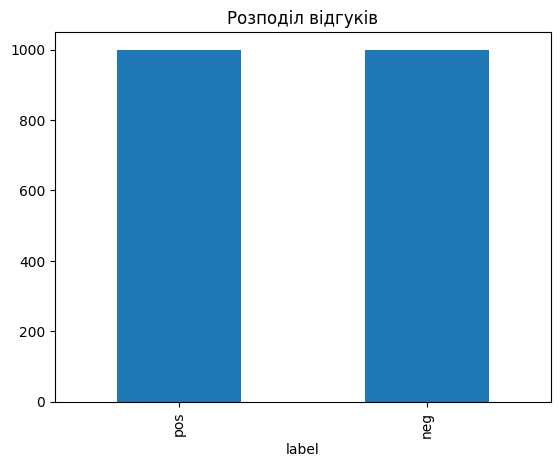

In [15]:
# Подивимося кількість позитивних і негативних
df['label'].value_counts().plot(kind='bar', title='Розподіл відгуків')

In [16]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['review'])  # матриця "слів" → "числа"
y = df['label']

In [17]:
print(X)
print(y)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 501022 stored elements and shape (2000, 25258)>
  Coords	Values
  (0, 19179)	2
  (0, 22703)	4
  (0, 7714)	14
  (0, 12393)	5
  (0, 9618)	1
  (0, 17655)	2
  (0, 22437)	6
  (0, 22242)	1
  (0, 17187)	2
  (0, 24496)	1
  (0, 17438)	1
  (0, 19520)	2
  (0, 7124)	1
  (0, 14140)	2
  (0, 13308)	2
  (0, 7119)	4
  (0, 13828)	1
  (0, 12944)	4
  (0, 8987)	4
  (0, 9598)	1
  (0, 19186)	2
  (0, 20600)	6
  (0, 13472)	12
  (0, 15547)	4
  (0, 12604)	1
  :	:
  (1999, 5592)	1
  (1999, 2687)	1
  (1999, 14337)	1
  (1999, 4627)	1
  (1999, 22547)	1
  (1999, 20878)	1
  (1999, 16914)	1
  (1999, 4997)	1
  (1999, 10492)	1
  (1999, 20230)	1
  (1999, 7664)	1
  (1999, 18291)	1
  (1999, 14380)	7
  (1999, 14050)	1
  (1999, 16439)	1
  (1999, 6340)	1
  (1999, 23979)	1
  (1999, 25124)	3
  (1999, 13148)	1
  (1999, 11414)	1
  (1999, 19885)	1
  (1999, 12605)	1
  (1999, 1943)	1
  (1999, 21120)	1
  (1999, 571)	1
0       pos
1       neg
2       neg
3       neg
4       ne

In [18]:
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB

# Ділимо дані на навчальні та тестові
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Створюємо модель наївного байєсівського класифікатора
model = MultinomialNB()

model.fit(X_train, y_train)

# Прогноз на тестових даних
y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix
print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.78


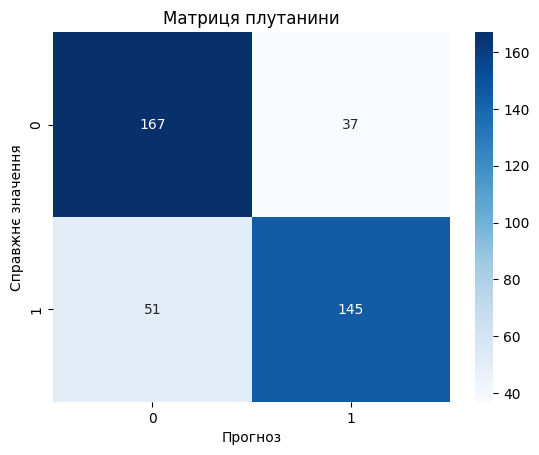

In [20]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Прогноз")
plt.ylabel("Справжнє значення")
plt.title("Матриця плутанини")
plt.show()

In [21]:
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [22]:
def predict_review(text: str) -> str:
  cleaned = " ".join(clear_words(word_tokenize(text)))
  vec = vectorizer.transform([cleaned])
  return model.predict(vec)[0]


In [23]:
type(predict_review("text"))


numpy.str_

In [28]:
print(predict_review("The film is interesting."))
print(predict_review("A good plot"))
print(predict_review("The genre isn't great."))
print(predict_review("The actors performed their roles poorly."))
print(predict_review("The movie was super—we really liked it."))
print(predict_review("It's just so-so."))
print(predict_review("I don't recommend it—the voice acting is a nightmare."))
print(predict_review("We really enjoyed it—we watched it as a whole family."))
print(predict_review("dkanwnfbaj"))
print(predict_review("Now this is my favorite movie."))
print(predict_review("qwerty"))

neg
neg
pos
neg
neg
pos
pos
pos
pos
neg
pos
